In [159]:
# ! pip install pycirclize

In [160]:
# imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pycirclize
from pycirclize import Circos
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import os

In [ ]:
# MAKE CHANGES HERE

# Input file used for analysis
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\combined_matrix_2lc.csv'

# Output directory for cluster usage change .csv files
output_dir = r'C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs'
os.makedirs(output_dir, exist_ok=True)

# Output directory for graphs. Use the path to .eps, .png will be automatically generated
eps_dir = r"C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps"

# Use any label for mouse
mouse_name = "2lc"  

**Function Definitions**

In [162]:
def create_cluster_usage_df( df ):
    df = pd.DataFrame( df )

    df_cluster_usage = df['Cluster'].value_counts().reset_index()
    df_cluster_usage.columns = ['Cluster', 'count']
    df_cluster_usage['count'] = df_cluster_usage['count'].astype( int )
    total_count = df_cluster_usage['count'].sum()
    df_cluster_usage['percentage'] = df_cluster_usage['count'] / total_count * 100

    return df_cluster_usage

In [163]:
# General, for all weeks

def compute_cluster_usage_change( week_dfs, week_early, week_late ):

    df_early = week_dfs[week_early]
    df_late = week_dfs[week_late]

    merged_df = pd.merge(
        df_early, df_late,
        on='Cluster', how='right',
        suffixes=(f'_{week_early}', f'_{week_late}')
    )

    merged_df[f'percentage_{week_early}'] = merged_df[f'percentage_{week_early}'].fillna(0)
    merged_df['change_in_usage'] = merged_df[f'percentage_{week_late}'] - merged_df[f'percentage_{week_early}']

    return merged_df[['Cluster', f'percentage_{week_early}', f'percentage_{week_late}', 'change_in_usage']]


In [164]:
def create_heatmaps_variable_periods(
    dfs,
    title="",
    save=False,
    paths=None,
    global_min=None,
    global_max=None,
    keys=None
):
   
    # Filter each DataFrame to same cluster range
    dfs = [df[(df['Cluster'] >= 1) & (df['Cluster'] <= 72)] for df in dfs]

    # Determine global color scale across all DataFrames
    all_changes = np.concatenate([df['change_in_usage'].values for df in dfs])
    if global_min is None:
        global_min = all_changes.min()
    if global_max is None:
        global_max = all_changes.max()

    # global_min = -4.774236665
    # global_max = 4.531974437158014

    norm = TwoSlopeNorm(vmin=global_min, vcenter=0, vmax=global_max)

    # Determine consistent cluster order (based on ascending ClusterNumber)
    all_clusters = sorted(set(np.concatenate([df['Cluster'].unique() for df in dfs])))

    titles = [
            f"Change in Cluster Usage Percentage ({title}) - {key.replace('_to_', ' → ').replace('_', ' ').title()}"
            for key in keys
    ]


    # Iterate through each DataFrame
    for i, df in enumerate(dfs):
        # Reorder to consistent cluster order
        df_ordered = (
            df.set_index("Cluster")
              .reindex(all_clusters)
              .fillna({"change_in_usage": 0})
              .reset_index()
        )

        clusters = df_ordered["Cluster"].astype(int).values
        change_values = df_ordered["change_in_usage"].values
        colors = plt.cm.bwr(norm(change_values))

        # Create polar plot
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
        theta = np.linspace(0, 2 * np.pi, len(clusters), endpoint=False)
        slice_width = 2 * np.pi / len(clusters)
        bar_width = slice_width * 0.9
        ax.bar(theta, np.ones(len(clusters)), color=colors, width=bar_width, bottom=0.5)

        # Axis formatting
        ax.set_xticks(theta)
        ax.set_xticklabels(clusters, fontsize=5.5, rotation=45)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.tick_params(axis="x", pad=-8)
        ax.grid(False)
        ax.spines["polar"].set_visible(False)

        # Colorbar (same normalization across all plots)
        sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.1)
        cbar.set_label("Change in Usage Percentage")

        plt.title(titles[i])
        plt.tight_layout()

        # --- Optional saving
        if save and paths and i < len(paths):
            path = paths[i]
            eps_dir = os.path.dirname(path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

**Analysis**

In [165]:
all_df = pd.read_csv( filename , index_col=0 )

# Creates list of dfs, one for each unique week within the dataset
week_dfs = {
    f"week{int(week)}": group_df.sort_values(by="Cluster", ascending=True).copy()
    for week, group_df in all_df.groupby("Week_Number", sort=True)
}

In [166]:
week_cluster_usages = {
    name: create_cluster_usage_df(df)
    for name, df in week_dfs.items()
}

In [167]:
week_cluster_usages.keys()

dict_keys(['week8', 'week10', 'week12', 'week14', 'week18'])

In [168]:
# The first week is your reference 
first_week = list(week_cluster_usages.keys())[0]

# Compute changes for all subsequent weeks compared to the first
cluster_usage_changes = {
    f"{first_week}_to_{week}": (
        compute_cluster_usage_change(week_cluster_usages, first_week, week)
        .sort_values(by="Cluster")
    )
    for week in list(week_cluster_usages.keys())[1:]  # skip the first week
}

In [169]:
cluster_usage_changes.keys()

dict_keys(['week8_to_week10', 'week8_to_week12', 'week8_to_week14', 'week8_to_week18'])

In [170]:
paths = [
    os.path.join(eps_dir, f"{mouse_name}_{key}.eps")
    for key in cluster_usage_changes.keys()
]

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2lc_week8_to_week10.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2lc_week8_to_week10.png


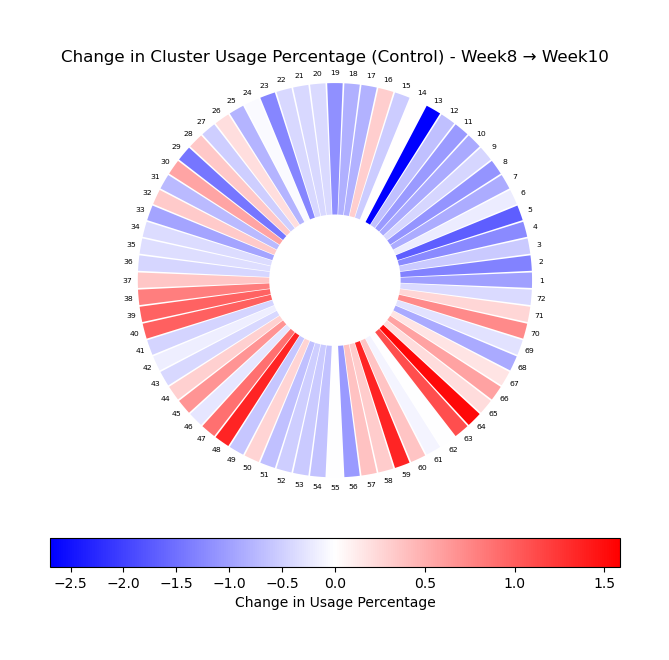

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2lc_week8_to_week12.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2lc_week8_to_week12.png


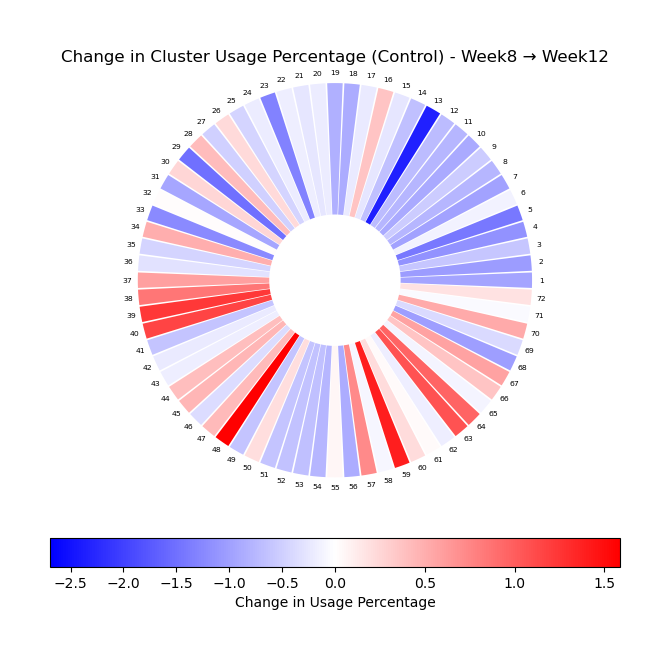

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2lc_week8_to_week14.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2lc_week8_to_week14.png


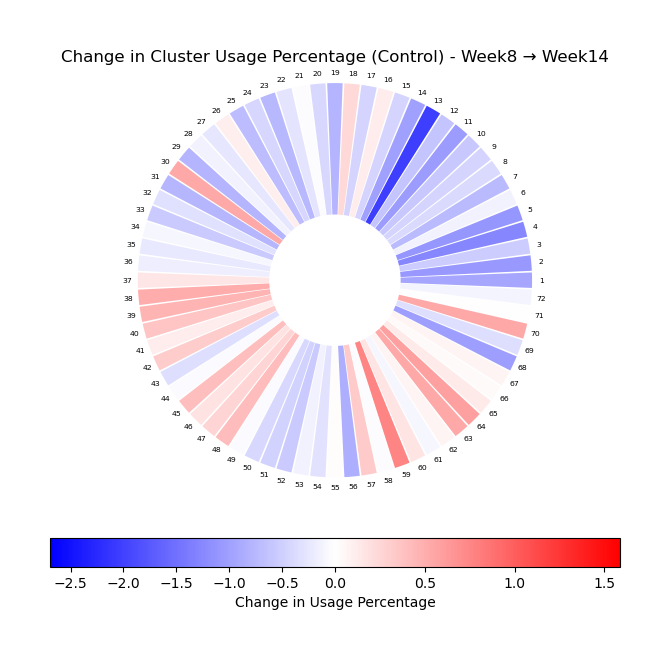

EPS saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2lc_week8_to_week18.eps
PNG saved to: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2lc_week8_to_week18.png


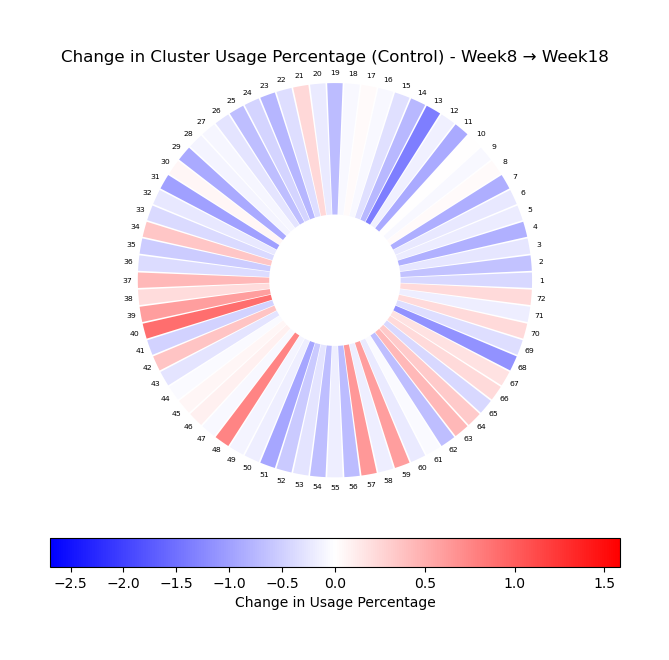

In [171]:
create_heatmaps_variable_periods(
    list(cluster_usage_changes.values()),
    title="Control",
    save=True,
    paths=paths,
    keys=list(cluster_usage_changes.keys())
)

In [172]:
for name, df in cluster_usage_changes.items():
    save_path = os.path.join(output_dir, f"cluster_usage_change_{name}.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

Saved: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\cluster_usage_change_week8_to_week10.csv
Saved: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\cluster_usage_change_week8_to_week12.csv
Saved: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\cluster_usage_change_week8_to_week14.csv
Saved: C:\Users\gangliaguardian\Documents\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\cluster_usage_change_week8_to_week18.csv
